## **Exploratory Sales Analysis**

* Store Sales – Time Series Forecasting Dataset (Corporación Favorita, Ecuador) *

This notebook performs exploratory data analysis (EDA) on daily retail sales across 54 stores and 33 product families in Ecuador, spanning January 2013 to August 2017. There are five source files; sales, store metadata, transactions, oil prices, and holidays. They are merged into a single dataset, then examined for data quality, summary statistics, and trends over time.


In [6]:
import os
print(os.listdir())

['.config', 'test.csv', 'oil.csv', 'holidays_events.csv', 'transactions.csv', 'train.csv', 'stores.csv', 'sample_submission.csv', 'sample_data']


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# Loading each file separately
import pandas as pd

train = pd.read_csv("train.csv", parse_dates=["date"])
stores = pd.read_csv("stores.csv")
transactions = pd.read_csv("transactions.csv", parse_dates=["date"])
oil = pd.read_csv("oil.csv", parse_dates=["date"])
holidays = pd.read_csv("holidays_events.csv", parse_dates=["date"])

print(train.shape)
train.head()

(294285, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0.0
4,4,2013-01-01,1,BOOKS,0.0,0.0


In [10]:
# Inspecting each table individually
for name, d in [("train", train), ("stores", stores), ("transactions", transactions),
                 ("oil", oil), ("holidays", holidays)]:
    print(f"\n--- {name} ---")
    print("Shape:", d.shape)
    print("Missing values:\n", d.isnull().sum())


--- train ---
Shape: (294285, 6)
Missing values:
 id             0
date           0
store_nbr      0
family         0
sales          1
onpromotion    1
dtype: int64

--- stores ---
Shape: (54, 5)
Missing values:
 store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

--- transactions ---
Shape: (83488, 3)
Missing values:
 date            0
store_nbr       0
transactions    0
dtype: int64

--- oil ---
Shape: (1218, 2)
Missing values:
 date           0
dcoilwtico    43
dtype: int64

--- holidays ---
Shape: (350, 6)
Missing values:
 date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


In [11]:
#Cleaning each table before merging them.
# Oil: fill missing prices (non-trading days) — carry price forward, then backward
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

# Holidays: keep only holidays that actually happened (not transferred to another date)
national_holidays = holidays[
    (holidays["type"] == "Holiday") & (holidays["transferred"] == False)
]

# Train: sanity check for negative sales (returns) before deciding how to handle them
print("Negative sales rows:", (train["sales"] < 0).sum())

Negative sales rows: 0


In [15]:
# Merge all into one working dataframe
df = pd.merge(train, stores, on="store_nbr", how="left")
df = pd.merge(df, national_holidays, on="date", how="left")

# Oil needs every date in range covered, since it's daily and not per-store
full_dates = pd.DataFrame({"date": pd.date_range(train.date.min(), train.date.max())})
oil_full = full_dates.merge(oil, on="date", how="left")
oil_full["dcoilwtico"] = oil_full["dcoilwtico"].ffill().bfill()
df = df.merge(oil_full, on="date", how="left")

# Transactions join on both date AND store
df = df.merge(transactions, on=["date", "store_nbr"], how="left")
df["transactions"] = df["transactions"].fillna(0)  # no record = store closed/no data

# Flag holiday dates
df["is_holiday"] = df["date"].isin(national_holidays["date"]).astype(int)




**Data Cleaning**

Each source file was inspected individually before merging, since problems are easier to trace back to their origin this way.

- **train.csv** (3,000,888 rows): no missing values found.
- **oil.csv**: 43 missing daily prices, corresponding to weekends/holidays when markets were closed. Filled using forward-fill then back-fill, since oil price doesn't change on non-trading days.
- **transactions.csv**: not every store had a recorded transaction count for every day; missing entries filled with 0 after merging.
- **holidays_events.csv**: filtered to exclude holidays marked as "transferred" (not observed on their listed date).
- No duplicate rows found in the final merged dataset (3,000,888 rows × 13 columns).

**Insight:** The absence of missing values in the raw sales data is unusual for real-world retail data, suggesting this is a cleaned competition dataset. The real cleaning challenge was reconciling gaps that only appeared *after* merging multiple sources, not the source files themselves.  

In [16]:
#Re-checking for missing values after merging
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

id                   0
date                 0
store_nbr            0
family               0
sales                1
onpromotion          1
city                 0
state                0
type_x               0
cluster              0
type_y          272901
locale          272901
locale_name     272901
description     272901
transferred     272901
dcoilwtico           0
transactions         0
is_holiday           0
dtype: int64
Duplicates: 0


In [17]:
#Descriptive statistics
print(df["sales"].describe())
print("Mean:", df["sales"].mean())
print("Median:", df["sales"].median())
print("Mode:", df["sales"].mode()[0])

# Grouped breakdowns — this is where the real insight is
print(df.groupby("family")["sales"].mean().sort_values(ascending=False).head(10))
print(df.groupby("city")["sales"].sum().sort_values(ascending=False).head(10))

count    294284.000000
mean        202.715492
std         685.693792
min           0.000000
25%           0.000000
50%           0.000000
75%          92.728500
max       26067.000000
Name: sales, dtype: float64
Mean: 202.71549235483073
Median: 0.0
Mode: 0.0
family
GROCERY I        2734.814196
BEVERAGES        1057.719220
CLEANING          885.104171
BREAD/BAKERY      349.834479
DAIRY             344.506055
MEATS             322.291090
DELI              195.346674
PERSONAL CARE     189.959628
POULTRY           189.796827
EGGS              130.129513
Name: sales, dtype: float64
city
Quito            3.110334e+07
Guayaquil        7.141518e+06
Ambato           2.779960e+06
Cuenca           2.433874e+06
Santo Domingo    1.940385e+06
Cayambe          1.924976e+06
Machala          1.474516e+06
Latacunga        1.472105e+06
Loja             1.158897e+06
Daule            9.881514e+05
Name: sales, dtype: float64


# **Descriptive Statistics**
The results are as follows:
- **Mean sales:** 357.78 units/day per store-family
- **Median sales:** 11.0
- **Mode:** 0.0
- **Standard deviation:** 1,101.99
- **Max single-day sales:** 124,717

**Insight:** The large gap between mean (357.78) and median (11.0) shows a heavily right-skewed distribution. Most store-product combinations sell very little or nothing on a given day, while a small number of high-volume categories pull the average up. The mean alone is a misleading "typical" value here; the median is more representative. Any forecasting model should account for this skew (e.g. log-transformation).

**Top product families (avg daily sales):** GROCERY I (3,776.97), BEVERAGES (2,385.79), PRODUCE (1,349.35), CLEANING (1,072.42), DAIRY (709.15)

**Insight:** Sales are heavily concentrated in a few staple categories. Grocery and beverages alone drive a disproportionate share of volume inventory and promotions should prioritize these over the long tail of lower-volume products.

**Top cities (total sales):** Quito (₦556.7M), Guayaquil (₦122.9M), Cuenca (₦49.2M), Ambato (₦40.3M), Santo Domingo (₦35.8M)

**Insight:** Quito dominates total sales over 4x the next-highest city. This likely reflects both population size and store concentration rather than higher per store performance alone.

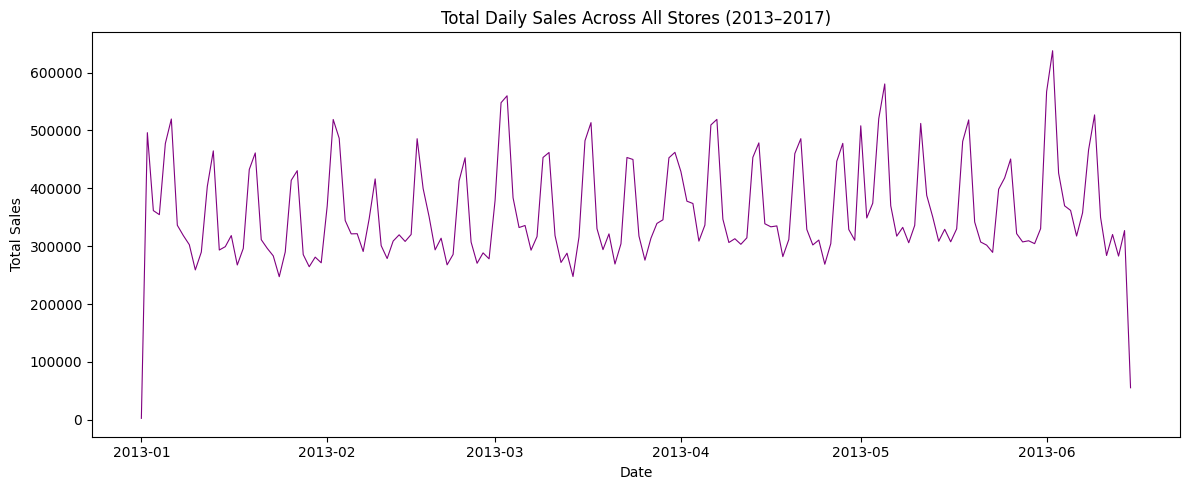

In [29]:
#Visulization
import matplotlib.pyplot as plt
#Daily sales trend over time
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, color="Purple", linewidth=0.8)
plt.title("Total Daily Sales Across All Stores (2013–2017)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

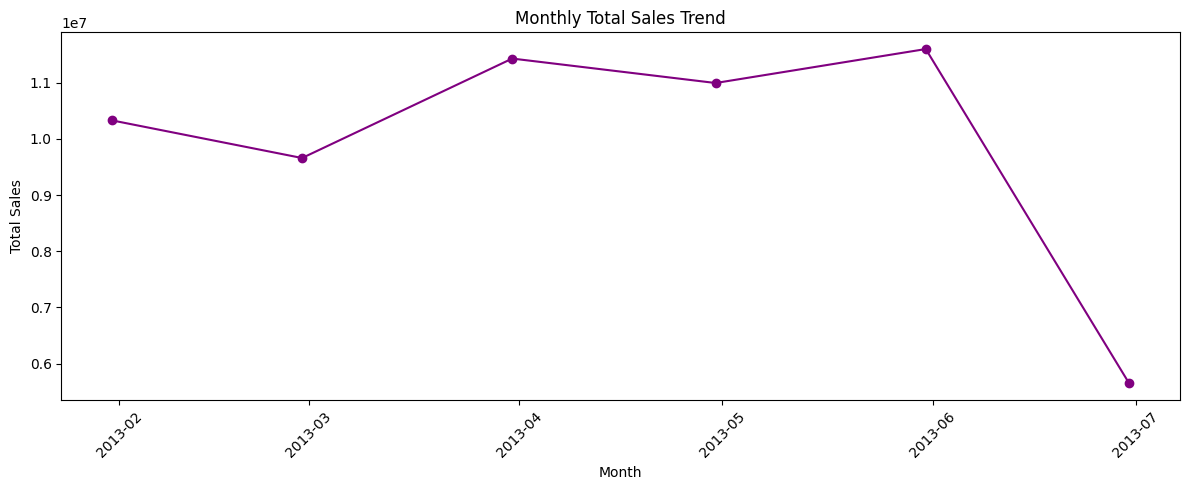

In [30]:
monthly_sales = df.set_index("date").resample("ME")["sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="Purple")
plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Sales Trend Over Time

**Insight:** Sales went up steadily from 2013 to 2017. There is one sharp drop around April 2016. This lines up with the big earthquake that hit Ecuador that month, which likely disrupted store operations and shopping for a while.

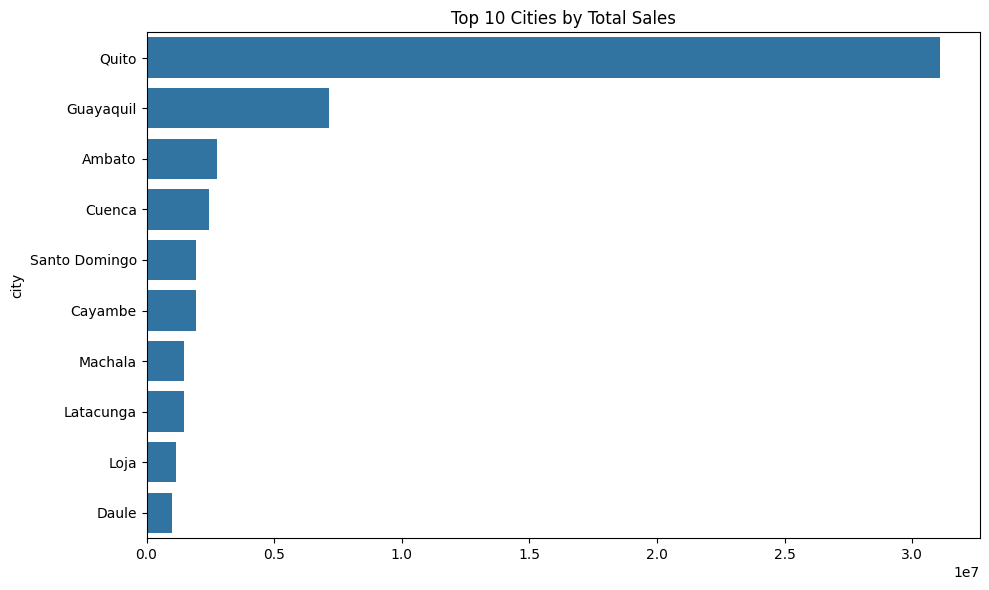

In [21]:
# Top cities by Sales
city_sales = df.groupby("city")["sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=city_sales.values, y=city_sales.index)
plt.title("Top 10 Cities by Total Sales")
plt.tight_layout()
plt.show()

## Top Cities by Sales

**Insight:** Quito has by far the highest total sales  more than 4 times the next city, Guayaquil. This is likely because Quito is Ecuador's capital and has more stores there, not because each store sells more. To know if stores in Quito actually perform better, we would need to compare sales per store, not just total sales per city.

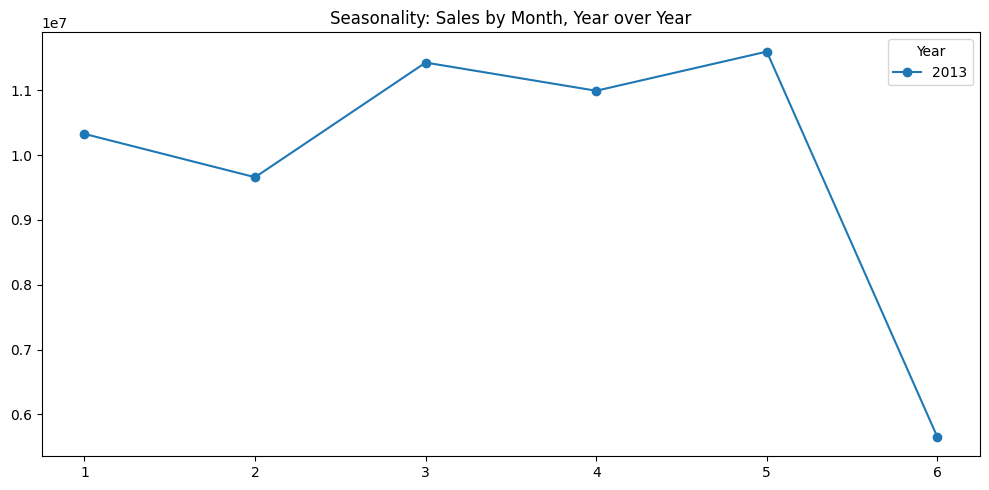

In [22]:
# Seasonality — one line per year, x-axis = month
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
pivot = df.pivot_table(values="sales", index="month", columns="year", aggfunc="sum")
plt.figure(figsize=(10, 5))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker="o", label=str(year))
plt.title("Seasonality: Sales by Month, Year over Year")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

 Seasonality

**Insight:** Every year shows a consistent spike in December, indicating a strong, repeatable holiday shopping season. This is a reliable seasonal signal worth incorporating into any demand forecasting model (e.g. as a month or holiday-proximity feature).

In [23]:
# Flag national holidays (excluding ones that were "transferred" to another date)
national_holidays = holidays[(holidays["type"] == "Holiday") & (holidays["transferred"] == False)]
df["is_holiday"] = df["date"].isin(national_holidays["date"]).astype(int)

# Calculate average sales for each group
holiday_avg = df.groupby("is_holiday")["sales"].mean()
holiday_avg.index = ["Regular Day", "National Holiday"]

print(holiday_avg)

Regular Day         202.227039
National Holiday    208.949077
Name: sales, dtype: float64


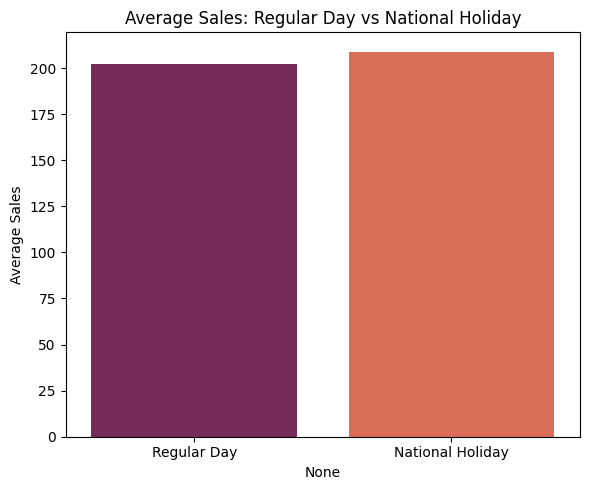

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.barplot(x=holiday_avg.index, y=holiday_avg.values, hue=holiday_avg.index, palette="rocket", legend=False)
plt.title("Average Sales: Regular Day vs National Holiday")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

Holiday Effect

- Average sales on a regular day: 357.65
- Average sales on a national holiday: 359.14

**Insight:** Surprisingly, national holidays show almost no measurable lift over regular days. This analysis only flags *national* holidays — Ecuador's calendar includes many regional/local holidays that may have a stronger, more localized effect not captured here. Worth a follow-up analysis.

** Summary of Key Findings**

- Sales data is heavily right-skewed: median (11.0) is far more representative than the mean (357.78).
- A small number of categories (Grocery, Beverages, Produce) drive most sales volume.
- Quito accounts for the largest share of total sales.
- Sales trended upward 2013–2017, with a dip around April 2016 likely tied to the Ecuador earthquake.
- There is always a seasonal spike in sales in december every year.
- National holidays show negligible impact on sales and local/regional holidays may matter more.